# Analysis Notebook

This notebook is for analysis of the saved data collected using the main_1.ipynb notebook.

In [88]:
# analysis notebook
%reset -f

# autoreload imports
%load_ext autoreload
%autoreload 2

# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import glob
import os
import re

import ipywidgets as widgets
from ipywidgets import HBox, VBox, Layout, Tab, Label, Checkbox
from ipywidgets import FloatSlider, IntSlider, Play, Dropdown, HTMLMath 
from IPython.display import display
from datetime import datetime
from time import sleep

# import plotly for interactive plots
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from Visualization.pop_plotting import plot_pop, pop_fit_plot, plot_quad
from Visualization.data_handling import load_data, sorted_sweep_files



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Testing model data saving and plotting code.

Reading data from Output_data/0001_c_sweep_0/simu_data_0001_c_1.0294444444444444_.csv
Generating population dynamics plot...


(<Figure size 1000x800 with 4 Axes>,
 array([[<Axes: title={'center': 'Populations over Time'}, xlabel='tau', ylabel='Population'>,
         <Axes: title={'center': 'Populations over Time'}, xlabel='tau', ylabel='Population'>],
        [<Axes: title={'center': 'Treatment over Time'}, xlabel='tau', ylabel='Dose'>,
         <Axes: title={'center': 'Fitness over Generations'}, xlabel='Generation', ylabel='Fitness'>]],
       dtype=object))

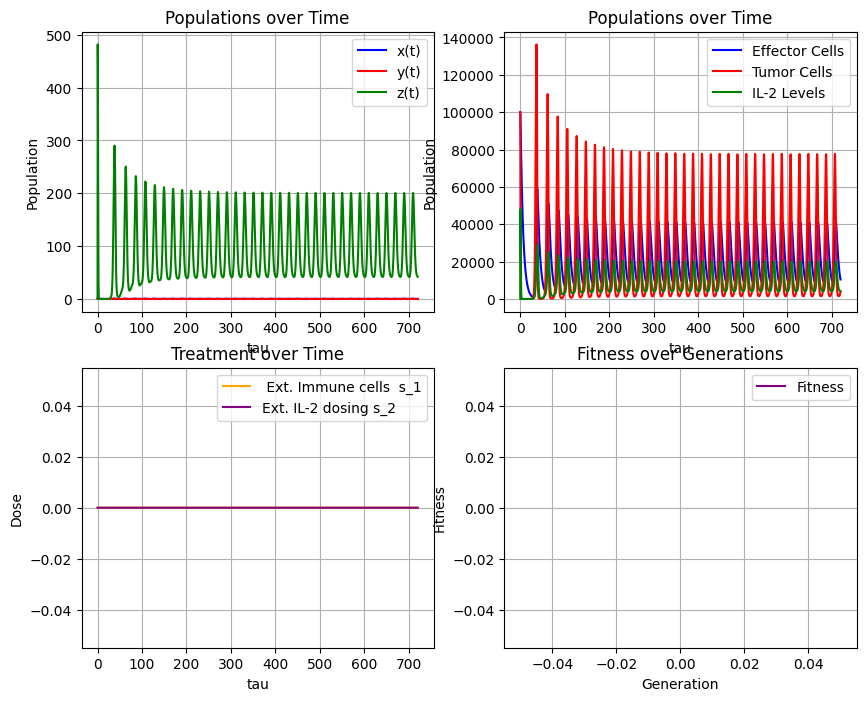

In [89]:
"""
Outputs like: ['Time_Step', 'tau', 'x', 'y', 'z', 'E', 'T', 'IL', 's_1_array', 's_2_array', 'Fitness']
"""

t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness = load_data('Output_data/0001_c_sweep_0/simu_data_0001_c_1.0294444444444444_.csv')

print("Generating population dynamics plot...")
plot_quad(t, tau, Fitness, x, y, z, E, T, IL, s_1_array, s_2_array)

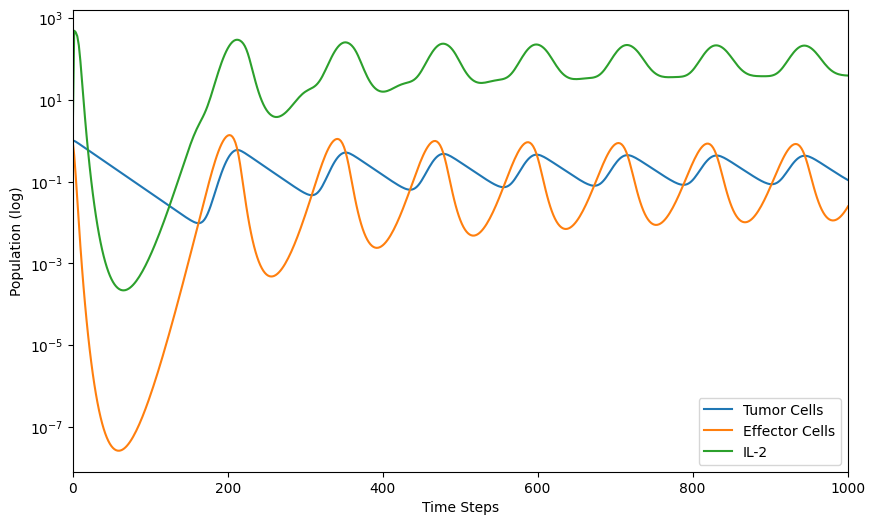

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(t, x, label='Tumor Cells')
plt.plot(t, y, label='Effector Cells')
plt.plot(t, z, label='IL-2')
plt.yscale('log')
plt.xlabel('Time Steps')
plt.ylabel('Population (log)')
plt.xlim(0, 1000)
plt.legend()
plt.show()

## Bifurcation analysis

The following code determines and plots these characteristics for each run vs the respective antigenicity value:
1. Amplitude in the last 400 time steps.
2. Maximum y from 400 to 1000.
3. Average y from 500 to 1500.
4. Bifurcation diagram

In [94]:
# get list of files in the output data directory
filepath_no_ga, antigenicity_values_no_ga = sorted_sweep_files(
    'Output_data/0001_c_sweep_0/simu_data_0001_c_*_.csv'
)


print(len(filepath_no_ga), "files found.")

# function to load data based on antigenicity value
def load_idx1(idx: int):
    path = filepath_no_ga[idx]

    """
    Outputs like: ['Time_Step', 'tau', 'x', 'y', 'z', 'E', 'T', 'IL', 's_1_array', 's_2_array', 'Fitness']
    """
    t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness = load_data(path)
    return t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness

# create arrays to hold antigenicity values and corresponding amplitudes
amplitudes = []
c_vals = []
max_vals = []
ave_vals = []
bifur_c0 = []
bifur_y0 = []

# find amplitudes for each file
for idx, f in enumerate(filepath_no_ga):
    df = pd.read_csv(f)
    
    y = df["y"].values
    tail = y[-400:]
    amp = tail.max() - tail.min()
    
    center = y[400:1000]
    max_val = center.max()

    center2 = y[500:1500]
    ave_val = center2.mean()

    tail = y[-1000:]
    c_val = antigenicity_values_no_ga[idx]
    bifur_c0.extend([c_val] * len(tail))
    bifur_y0.extend(tail.tolist())
    
    amplitudes.append(amp)
    c_vals.append(antigenicity_values_no_ga[idx])
    max_vals.append(max_val)
    ave_vals.append(ave_val)

c_vals_0 = np.array(c_vals)
amplitudes_0 = np.array(amplitudes)
max_0 = np.array(max_vals)
ave_0 = np.array(ave_vals)
bifur_c0 = np.array(bifur_c0)
bifur_y0 = np.array(bifur_y0)




100 files found.


In [156]:
# get list of files in the output data directory
filepath_w_ga, antigenicity_values_ga = sorted_sweep_files(
    'Output_data/0004_c_sweep_ga_1/simu_data_0003_c_ga_*_.csv'
)

print(len(filepath_w_ga), "files found.")

# function to load data based on antigenicity value
def load_idx(idx: int):
    path = filepath_w_ga[idx]

    """
    Outputs like: ['Time_Step', 'tau', 'x', 'y', 'z', 'E', 'T', 'IL', 's_1_array', 's_2_array', 'Fitness']
    """
    t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness = load_data(path)
    return t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness

# create arrays to hold antigenicity values and corresponding amplitudes
amplitudes = []
c_vals = []
max_vals = []
ave_vals = []

# find amplitudes for each file
for idx, f in enumerate(filepath_w_ga):
    df = pd.read_csv(f)
    
    y = df["y"].values
    tail = y[-400:]
    amp = tail.max() - tail.min()

    center = y[400:1000]
    max_val = center.max()

    center2 = y[500:1500]
    ave_val = center2.mean()

    tail = y[-1000:]
    c_val = antigenicity_values_ga[idx]

    
    amplitudes.append(amp)
    c_vals.append(antigenicity_values_ga[idx])
    max_vals.append(max_val)
    ave_vals.append(ave_val)

c_vals_1 = np.array(c_vals)
amplitudes_1 = np.array(amplitudes)
max_1 = np.array(max_vals)
ave_1 = np.array(ave_vals)



100 files found.


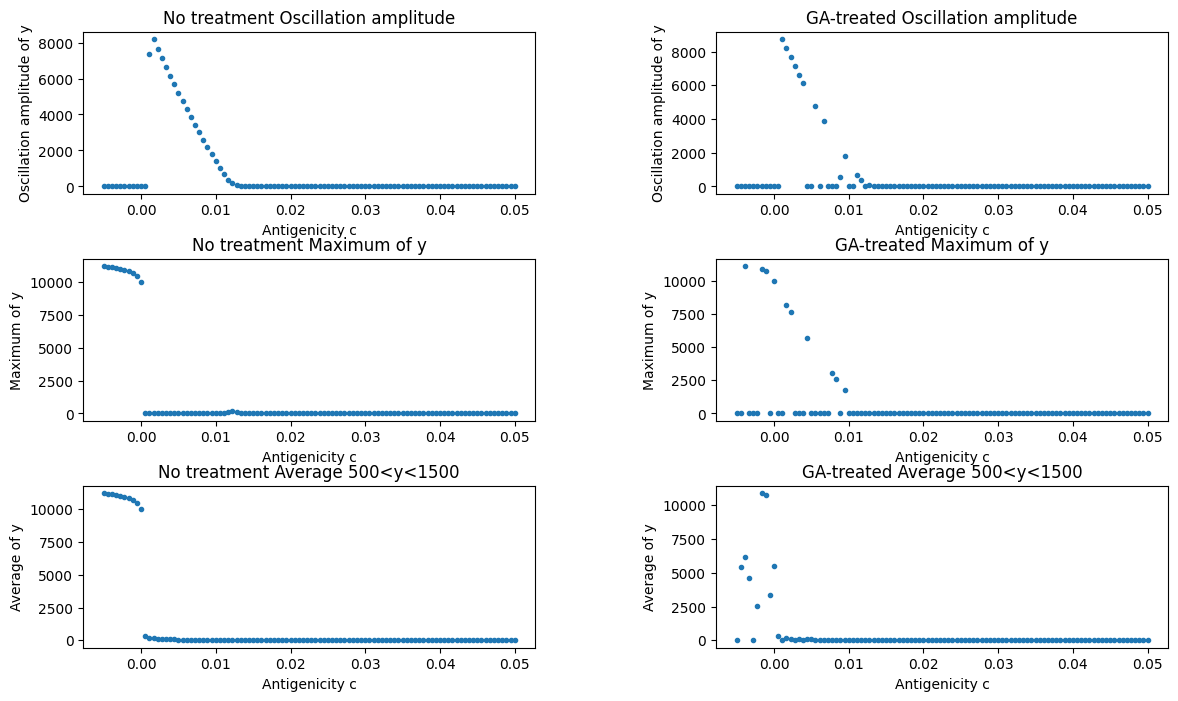

In [157]:
plt.figure(figsize=(14,8))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(3,2,1)
plt.scatter(c_vals_0, amplitudes_0, marker='.', label='No GA, no therapy')
plt.xlabel("Antigenicity c")
plt.ylabel("Oscillation amplitude of y")
plt.title("No treatment Oscillation amplitude")

plt.subplot(3,2,2)
plt.scatter(c_vals_1, amplitudes_1, marker='.', label='With GA, with therapy')
plt.xlabel("Antigenicity c")
plt.ylabel("Oscillation amplitude of y")
plt.title("GA-treated Oscillation amplitude")

plt.subplot(3,2,3)
plt.scatter(c_vals_0, max_0, marker='.', label='No GA, no therapy')
plt.xlabel("Antigenicity c")
plt.ylabel("Maximum of y")
plt.title("No treatment Maximum of y")

plt.subplot(3,2,4)
plt.scatter(c_vals_1, max_1, marker='.', label='With GA, with therapy')
plt.xlabel("Antigenicity c")
plt.ylabel("Maximum of y")
plt.title("GA-treated Maximum of y")

plt.subplot(3,2,5)
plt.scatter(c_vals_0, ave_0, marker='.', label='Average 500<y<1500')
plt.xlabel("Antigenicity c")
plt.ylabel("Average of y")
plt.title("No treatment Average 500<y<1500")

plt.subplot(3,2,6)
plt.scatter(c_vals_1, ave_1, marker='.', label='Average 500<y<1500')
plt.xlabel("Antigenicity c")
plt.ylabel("Average of y")
plt.title("GA-treated Average 500<y<1500")

plt.show()

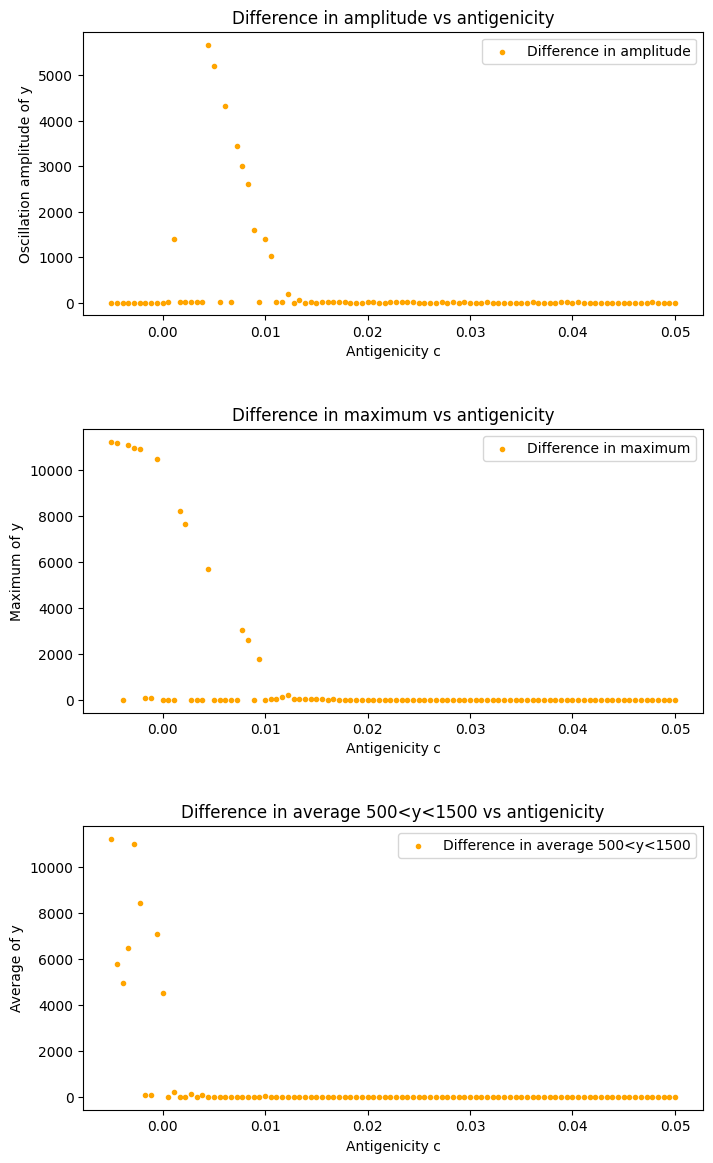

In [158]:
plt.figure(figsize=(8, 14))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(3,1,1)
plt.scatter(c_vals_0, abs(amplitudes_0 - amplitudes_1), marker='.', color='orange', label='Difference in amplitude')
plt.xlabel("Antigenicity c")
plt.ylabel("Oscillation amplitude of y")
plt.title("Difference in amplitude vs antigenicity")
plt.legend()

plt.subplot(3,1,2)
plt.scatter(c_vals_0, abs(max_0 - max_1), marker='.', color='orange', label='Difference in maximum')
plt.xlabel("Antigenicity c")
plt.ylabel("Maximum of y")
plt.title("Difference in maximum vs antigenicity")
plt.legend()

plt.subplot(3,1,3)
plt.scatter(c_vals_0, abs(ave_0 - ave_1), marker='.', color='orange', label='Difference in average 500<y<1500')
plt.xlabel("Antigenicity c")
plt.ylabel("Average of y")
plt.title("Difference in average 500<y<1500 vs antigenicity")
plt.legend()

plt.show()

In [159]:
from scipy.signal import find_peaks

bifur_c = []
bifur_y = []

for idx, f in enumerate(filepath_w_ga):
    df = pd.read_csv(f)
    y = df["y"].values
    tail = y[-1000:]
    c_val = antigenicity_values_ga[idx]

    peaks, _ = find_peaks(tail)
    peak_vals = tail[peaks]

    bifur_c.extend([c_val] * len(peak_vals))
    bifur_y.extend(peak_vals.tolist())

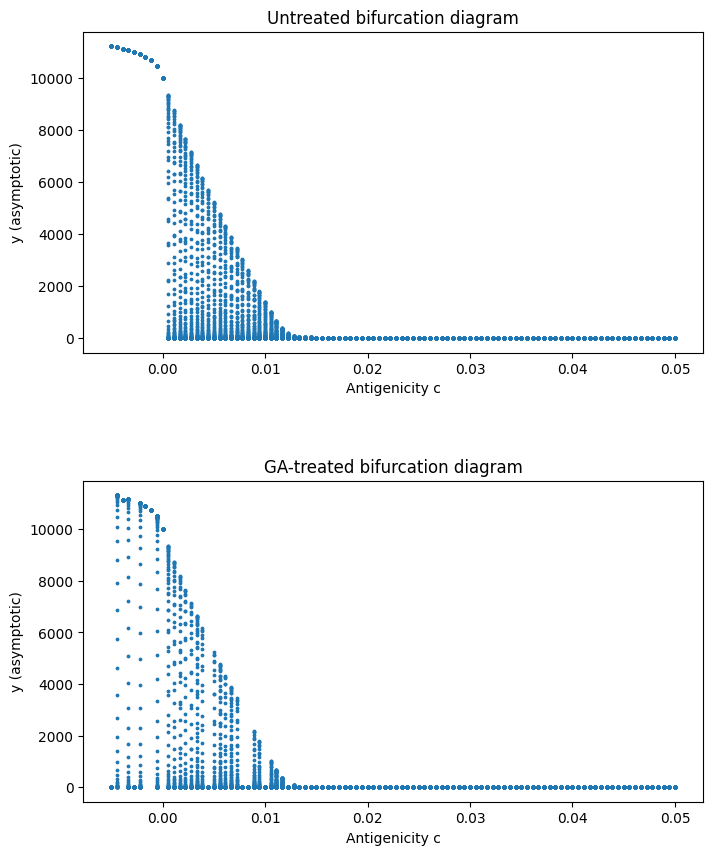

In [160]:

plt.figure(figsize=(8, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

plt.subplot(2,1,1)
plt.scatter(bifur_c0, bifur_y0, s=3)
plt.xlabel("Antigenicity c")
plt.ylabel("y (asymptotic)")
plt.title("Untreated bifurcation diagram")

plt.subplot(2,1,2)
plt.scatter(bifur_c1, bifur_y1, s=3)
plt.xlabel("Antigenicity c")
plt.ylabel("y (asymptotic)")
plt.title("GA-treated bifurcation diagram")
plt.show()

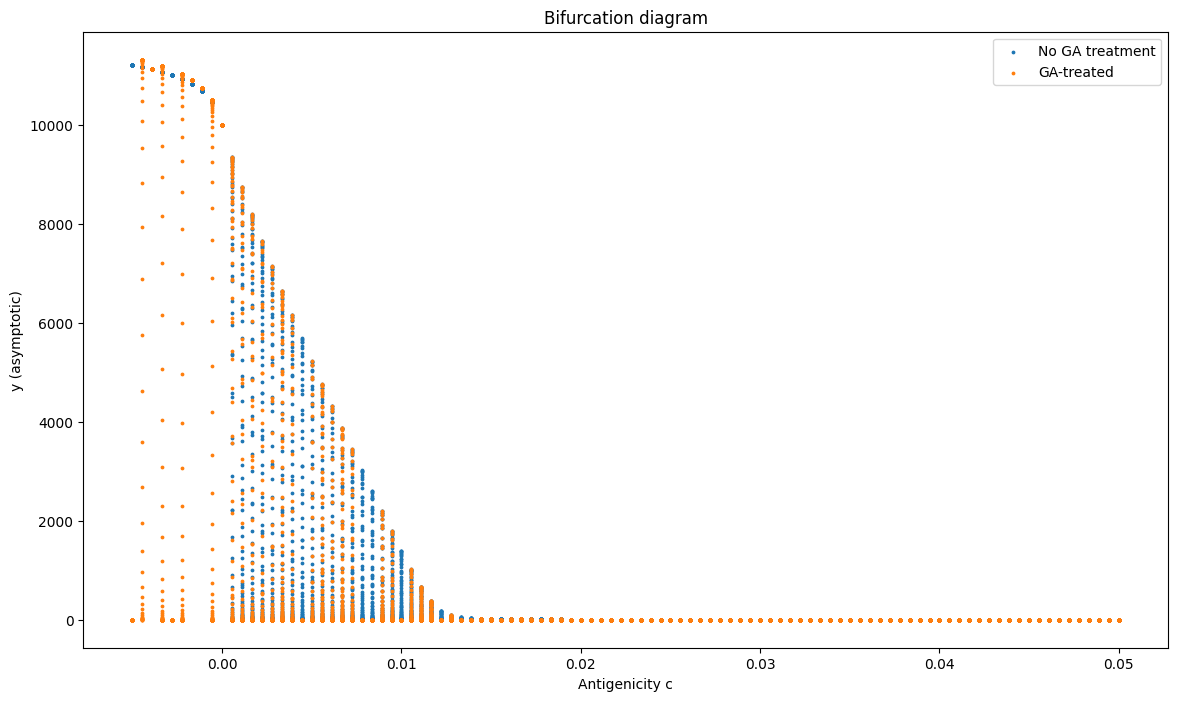

In [161]:

plt.figure(figsize=(14, 8))

plt.scatter(bifur_c0, bifur_y0, s=3, label='No GA treatment')
plt.scatter(bifur_c1, bifur_y1, s=3, label='GA-treated')

plt.xlabel("Antigenicity c")
plt.ylabel("y (asymptotic)")
plt.title("Bifurcation diagram")
plt.legend(loc='upper right')
plt.show()

# UMAP plot

The UMAP plots below are used to represent multi-dimension characteristics of simulation runs reducing them into a 2-dimensional space.
This allows a lot of information to be represented in a 2D plot.

In [100]:
from Visualization.data_handling import extract_features, osc_features

# get list of files in the output data directory
filepath_non, antigenicity_values_no_ga = sorted_sweep_files(
    'Output_data/0001_c_sweep_0/simu_data_0001_c_*_.csv'
)
print(len(filepath_non), "files found.")

# get list of files in the output data directory
filepath_GA, antigenicity_values_ga = sorted_sweep_files(
    'Output_data/0004_c_sweep_ga_1/simu_data_0003_c_ga_*_.csv'
)
print(len(filepath_GA), "files found.")

# function to load data based on antigenicity value
def load_idx_non(idx: int):
    path = filepath_non[idx]

    """
    Outputs like: ['Time_Step', 'tau', 'x', 'y', 'z', 'E', 'T', 'IL', 's_1_array', 's_2_array', 'Fitness']
    """
    t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness = load_data(path)
    return t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness

def load_idx_ga(idx: int):
    path = filepath_GA[idx]

    """
    Outputs like: ['Time_Step', 'tau', 'x', 'y', 'z', 'E', 'T', 'IL', 's_1_array', 's_2_array', 'Fitness']
    """
    t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness = load_data(path)
    return t, tau, x, y, z, E, T, IL, s_1_array, s_2_array, Fitness


100 files found.
100 files found.


In [101]:
# UMAP dimensionality reduction
import umap
from sklearn.preprocessing import StandardScaler

# extract features
features_non, c_vals_non, amp_non = extract_features(filepath_non, antigenicity_values_no_ga)
features_GA, c_vals_GA, amp_GA = extract_features(filepath_GA, antigenicity_values_ga)

# extract oscillatory features
y_values_non, amp_values_non, freq_values_non, osc_c_vals_non = osc_features(filepath_non, antigenicity_values_no_ga)
y_values_GA, amp_values_GA, freq_values_GA, osc_c_vals_GA = osc_features(filepath_GA, antigenicity_values_ga)

print("Feature extraction complete.\n")

print("Non-GA features shape:")
print(np.shape(features_non))

print("GA features shape:")
print(np.shape(features_GA))

print("Non-GA oscillatory features shape:")
print(np.shape(y_values_non))
print(np.shape(amp_values_non))
print(np.shape(freq_values_non))

print("GA oscillatory features shape:")
print(np.shape(y_values_GA))
print(np.shape(amp_values_GA))
print(np.shape(freq_values_GA))

Feature extraction complete.

Non-GA features shape:
(100, 6)
GA features shape:
(100, 6)
Non-GA oscillatory features shape:
(4, 100, 500)
(4, 100, 500)
(4, 100, 500)
GA oscillatory features shape:
(4, 100, 500)
(4, 100, 500)
(4, 100, 500)


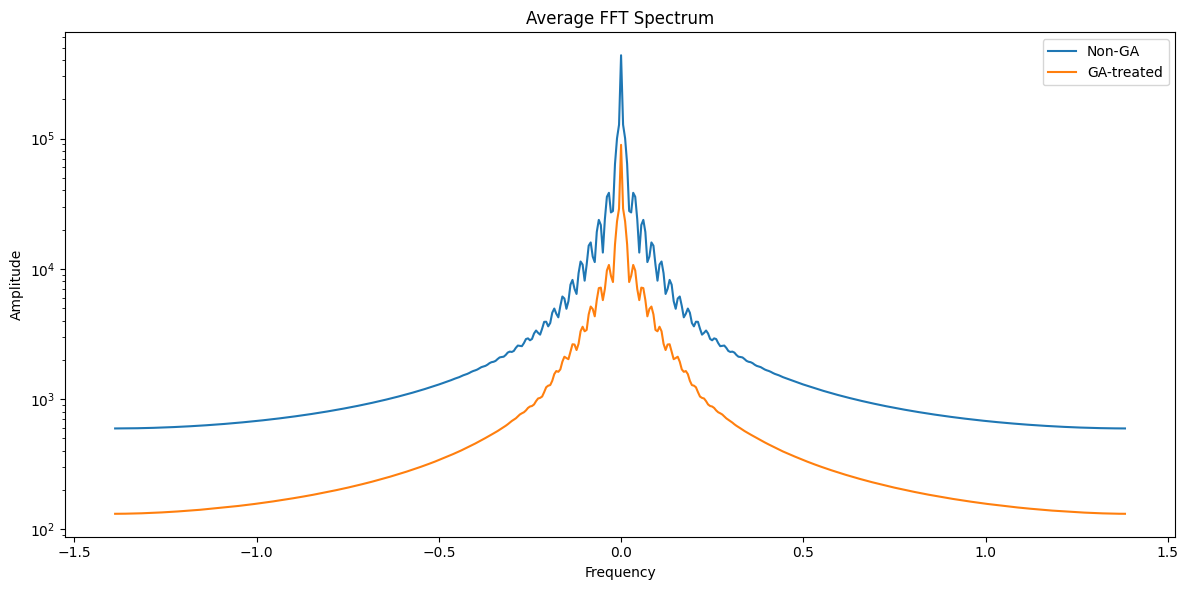

In [153]:
from scipy.fft import fftshift

spec_non = np.mean(np.abs(y_values_non[0]), axis=0)
spec_ga = np.mean(np.abs(y_values_GA[0]), axis=0)

xf_non = fftshift(freq_values_non[0][0, :])
xf_ga = fftshift(freq_values_GA[0][0, :])

yplot_non = fftshift(spec_non)
yplot_ga = fftshift(spec_ga)

plt.figure(figsize=(12, 6))

plt.plot(xf_non, yplot_non, label='Non-GA')
plt.plot(xf_ga, yplot_ga, label='GA-treated')
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.title("Average FFT Spectrum")

plt.yscale('log')

plt.legend()
plt.tight_layout()
plt.show()

In [110]:
# perform UMAP dimensionality reduction
labels = np.array([0]*len(features_non) + [1]*len(features_GA))
label_non = (labels == 0)
label_GA = (labels == 1)

# UMAP reducer
reducer = umap.UMAP(random_state=42)

x = np.vstack((features_non, features_GA))
x = StandardScaler().fit_transform(x)
embedding = reducer.fit_transform(x)

# Embeddings for non-GA and GA-treated data
embedding_non = embedding[label_non, :]
embedding_GA = embedding[label_GA, :]


/opt/anaconda3/envs/Tumor_GA_v1/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



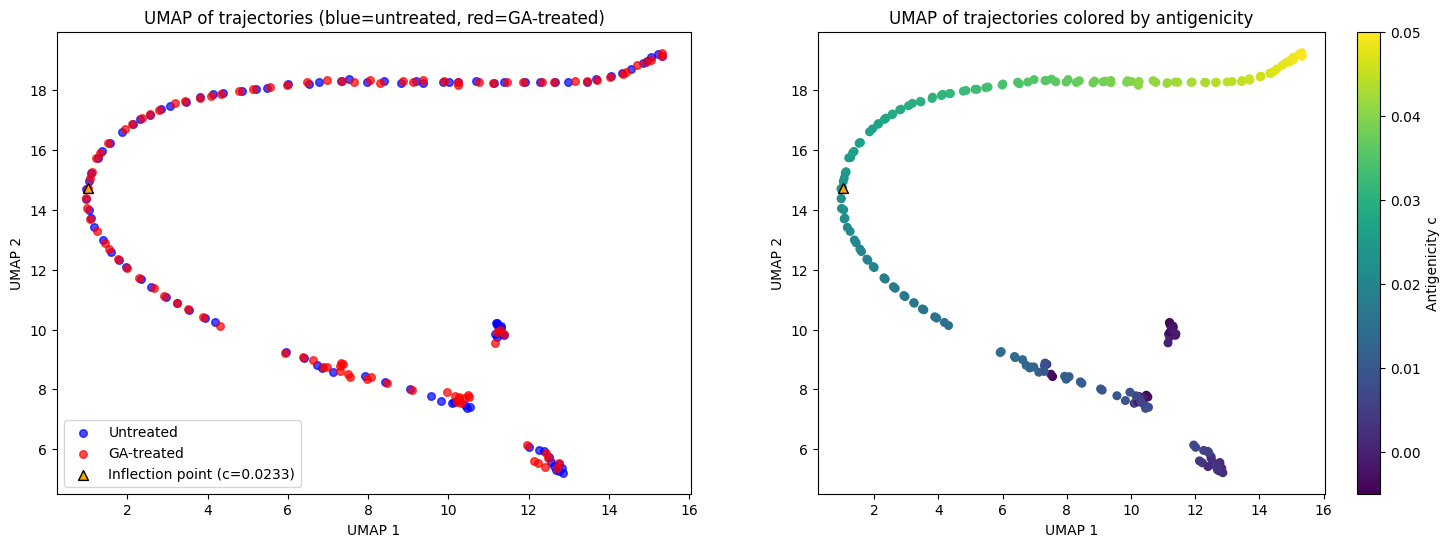

In [ ]:
# Mode change value
init_antigenicity = 0.0233 #0.0297
init_idx = int(np.argmin(np.abs(np.concatenate([c_vals_non, c_vals_GA]) - init_antigenicity))) # find index closest to initial value

plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
sc1 = plt.scatter(embedding_non[:, 0], embedding_non[:, 1], c='blue', s=30, alpha=0.7, label='Untreated')
sc2= plt.scatter(embedding_GA[:, 0], embedding_GA[:, 1], c='red', s=30, alpha=0.7, label='GA-treated')
sc2_inflection = plt.scatter(embedding_GA[init_idx, 0], embedding_GA[init_idx, 1], c='orange', edgecolors='black', marker='^', s=50, label=f'Inflection point (c={init_antigenicity})')

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of trajectories (blue=untreated, red=GA-treated)")
plt.legend()

plt.subplot(1,2,2)
labels_c = np.concatenate([c_vals_non, c_vals_GA])
sc3 = plt.scatter(embedding[:,0], embedding[:,1], c=labels_c, cmap='viridis', s=30)
sc3_inflection = plt.scatter(embedding_GA[init_idx, 0], embedding_GA[init_idx, 1], c='orange', edgecolors='black', marker='^', s=50, label=f'Inflection point (c={init_antigenicity})')
plt.colorbar(sc3, label='Antigenicity c')

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of trajectories colored by antigenicity")

plt.show()

### Look deeper into the plots

KMeans cluster labels: 200
Cluster 0: n=104, mean amp = 1350.7709, std amp = 2509.7573, min = 0.0000, max = 8747.0301
Cluster 1: n=96, mean amp = 1.7776, std amp = 2.9850, min = 0.0000, max = 15.6630


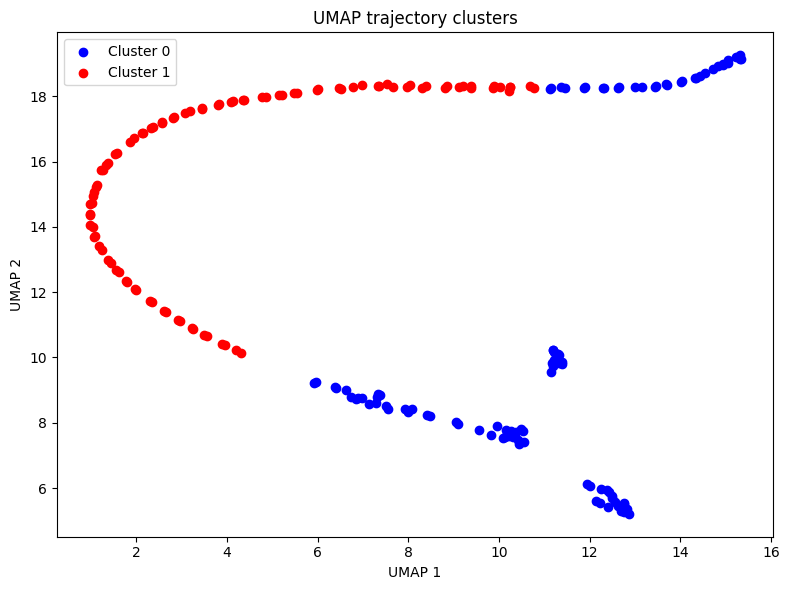

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(embedding)
cluster_labels = kmeans.labels_
print ("KMeans cluster labels:", len(cluster_labels))

amp_concat = np.concatenate([amp_non, amp_GA])

plt.figure(figsize=(8,6))
colors = ['blue', 'red', 'orange']

# plot isolated clusters
for i in range(n_clusters):
    cluster_points = embedding[cluster_labels == i]
    cluster_c = labels_c[cluster_labels == i]
    cluster_amp = amp_concat[cluster_labels == i]
    print(f"Cluster {i}: n={len(cluster_points)}, "
          f"mean amp = {cluster_amp.mean():.4f}, "
          f"std amp = {cluster_amp.std():.4f}, "
          f"min = {cluster_amp.min():.4f}, "
          f"max = {cluster_amp.max():.4f}")
    
    # plot cluster points to ensure they are separated
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}')

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP trajectory clusters")
plt.legend()

plt.tight_layout()
plt.show()


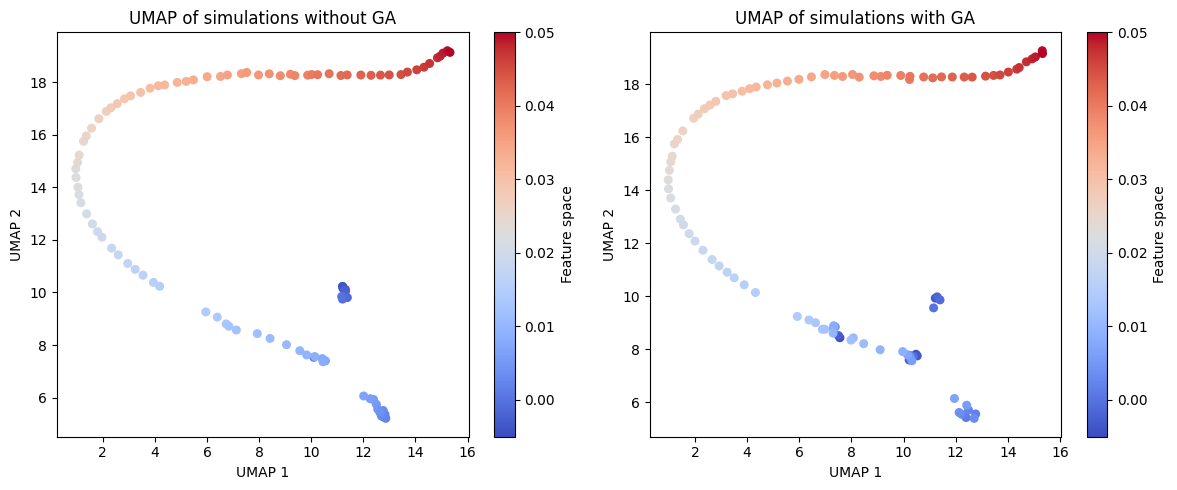

In [123]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sc_non = plt.scatter(embedding_non[:,0], embedding_non[:,1],
            c=features_non[:,0], cmap='coolwarm', s=30, label='Untreated')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of simulations without GA")
plt.colorbar(sc_non, label='Feature space')

plt.subplot(1,2,2)
sc_GA = plt.scatter(embedding_GA[:,0], embedding_GA[:,1],
            c=features_GA[:,0], cmap='coolwarm', s=30, label='GA-treated')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of simulations with GA")
plt.colorbar(sc_GA, label='Feature space')

plt.tight_layout()
plt.show()